### Load the cleaned dataset and Lasso Model

In [116]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
import numpy as np

# Load preprocessed data
df = pd.read_csv('../data/clean_encoded_insurance.csv')

# Separate target
y = df['Premium Amount']
X = df.select_dtypes(include=['float64','int64']).drop(columns=['id','Premium Amount'])

# Standardize (same as your previous Lasso)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Train Lasso

In [117]:
from sklearn.linear_model import LassoCV
import numpy as np

# Log-transform the target to handle skewed premium distribution
y_log = np.log1p(y)

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_scaled, y_log)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


### Extract coefficients and normalize to weights

In [118]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': lasso.coef_
})
coef_df['abs_coef'] = coef_df['coef'].abs()

# Normalize to [0, 1] scale
coef_df['weight'] = coef_df['abs_coef'] / coef_df['abs_coef'].max()

# Keep only non-zero weights (selected features)
lasso_features = coef_df[coef_df['weight'] > 0]
print(lasso_features)

                feature      coef  abs_coef    weight
0                   Age -0.001571  0.001571  0.015153
1         Annual Income -0.103702  0.103702  1.000000
2  Number of Dependents -0.003039  0.003039  0.029310
3          Health Score  0.020003  0.020003  0.192889
4       Previous Claims  0.041619  0.041619  0.401333
6          Credit Score -0.072315  0.072315  0.697332


### Compute the continuous Risk Score


In [119]:
coef_df = pd.DataFrame({'feature': X.columns, 'coef': lasso.coef_})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df['weight'] = coef_df['abs_coef'] / coef_df['abs_coef'].max()

# Recompute weights using the new log-transformed Lasso model
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': lasso.coef_
})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df['weight'] = coef_df['abs_coef'] / coef_df['abs_coef'].max()

weights = coef_df.set_index('feature')['weight'].reindex(X.columns).fillna(0).values
X_weighted = X_scaled * weights
risk_score = X_weighted.sum(axis=1)

# Normalize 0–1 for interpretability
df['Risk_Score_Lasso_Log'] = (risk_score - risk_score.min()) / (risk_score.max() - risk_score.min())

### Create discrete classes

In [120]:
bins = df['Risk_Score_Lasso_Log'].quantile([0, 0.33, 0.66, 1.0])
df['Risk_Class_Lasso_Log'] = pd.cut(
    df['Risk_Score_Lasso_Log'],
    bins=bins,
    labels=['Low','Medium','High'],
    include_lowest=True
)

### Validate the new index

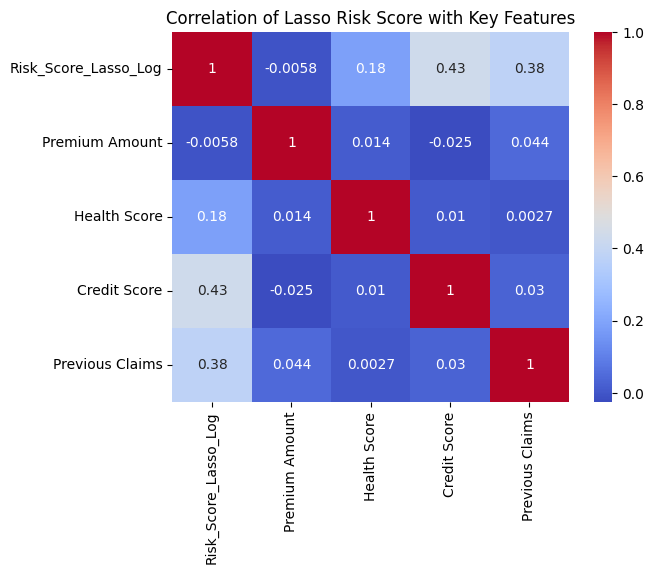

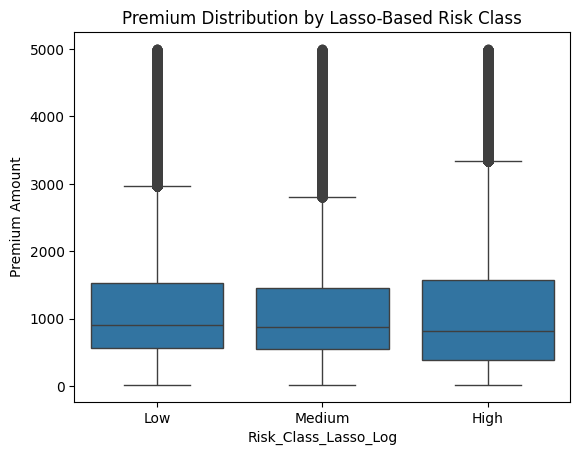

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation check
corrs = df[['Risk_Score_Lasso_Log','Premium Amount','Health Score','Credit Score','Previous Claims']].corr()
sns.heatmap(corrs, annot=True, cmap='coolwarm')
plt.title('Correlation of Lasso Risk Score with Key Features')
plt.show()

# Distribution check
sns.boxplot(x='Risk_Class_Lasso_Log', y='Premium Amount', data=df)
plt.title('Premium Distribution by Lasso-Based Risk Class')
plt.show()

### Save results for integration

In [122]:
df[['id','Risk_Score_Lasso_Log','Risk_Class_Lasso_Log']].to_csv('../data/risk_index_lasso.csv', index=False)

### Risk Class Distribution

/var/folders/l_/2vlw7m7d75n2_mk6fws8dmgr0000gn/T/ipykernel_81042/3375133006.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Risk_Class_Lasso_Log', data=df, order=['Low','Medium','High'], palette='coolwarm')


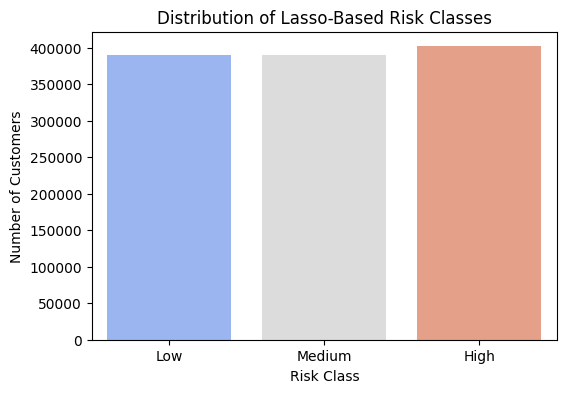

Risk_Class_Lasso_Log
High      34.0
Low       33.0
Medium    33.0
Name: proportion, dtype: float64


In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Risk_Class_Lasso_Log', data=df, order=['Low','Medium','High'], palette='coolwarm')
plt.title('Distribution of Lasso-Based Risk Classes')
plt.xlabel('Risk Class')
plt.ylabel('Number of Customers')
plt.show()

# Optional percentage labels
counts = df['Risk_Class_Lasso_Log'].value_counts(normalize=True) * 100
print(counts.round(2))

### Premium vs. Risk Class (Boxplot)

/var/folders/l_/2vlw7m7d75n2_mk6fws8dmgr0000gn/T/ipykernel_81042/1788964973.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk_Class_Lasso_Log', y='Premium Amount', data=df, order=['Low','Medium','High'], palette='RdYlBu_r')


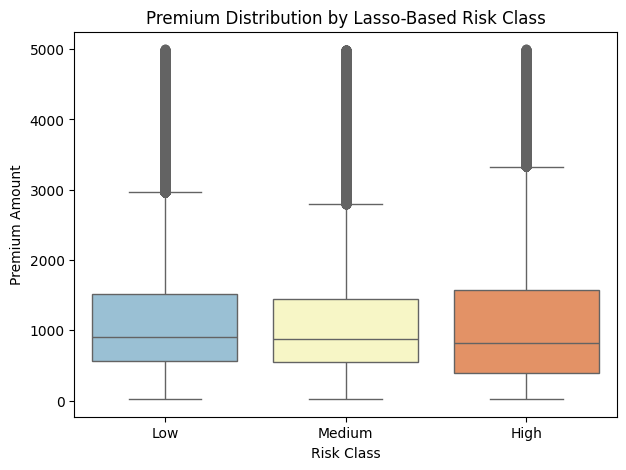

In [124]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Risk_Class_Lasso_Log', y='Premium Amount', data=df, order=['Low','Medium','High'], palette='RdYlBu_r')
plt.title('Premium Distribution by Lasso-Based Risk Class')
plt.xlabel('Risk Class')
plt.ylabel('Premium Amount')
plt.show()

### Correlation Heatmap

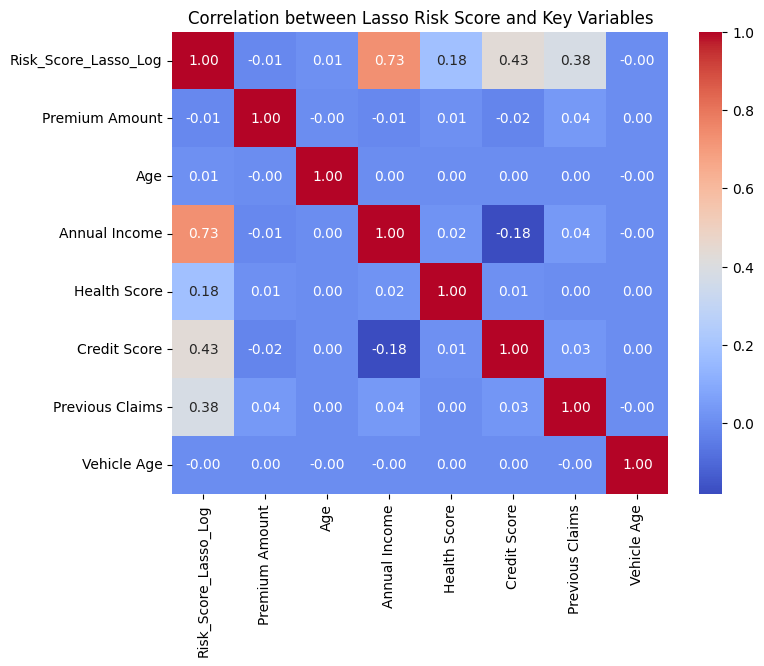

In [125]:
num_features = ['Risk_Score_Lasso_Log', 'Premium Amount', 'Age', 'Annual Income',
                'Health Score', 'Credit Score', 'Previous Claims', 'Vehicle Age']

corr = df[num_features].corr().round(2)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between Lasso Risk Score and Key Variables')
plt.show()

### Lasso Feature Importance Plot

/var/folders/l_/2vlw7m7d75n2_mk6fws8dmgr0000gn/T/ipykernel_81042/409403912.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='abs_coef', y='feature', data=top_features, palette='viridis')


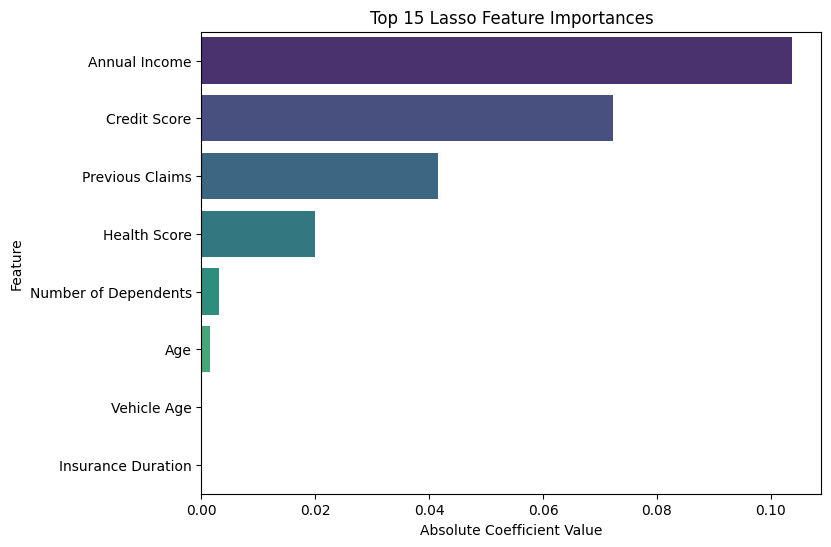

In [126]:
top_features = coef_df.sort_values('abs_coef', ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x='abs_coef', y='feature', data=top_features, palette='viridis')
plt.title('Top 15 Lasso Feature Importances')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.show()

<Axes: xlabel='Risk_Score_Lasso_Log', ylabel='Premium Amount'>

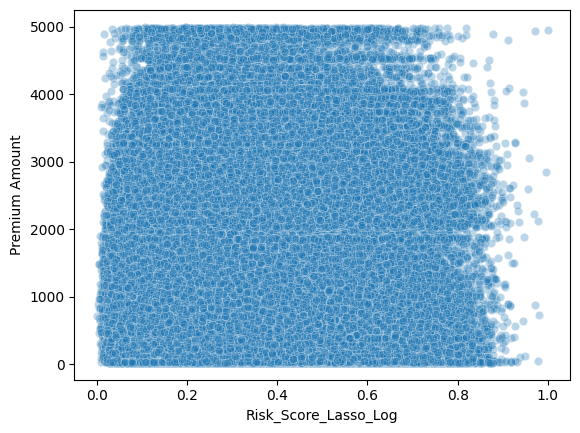

In [127]:
sns.scatterplot(x='Risk_Score_Lasso_Log', y='Premium Amount', data=df, alpha=0.3)

<Axes: xlabel='Premium Amount', ylabel='Count'>

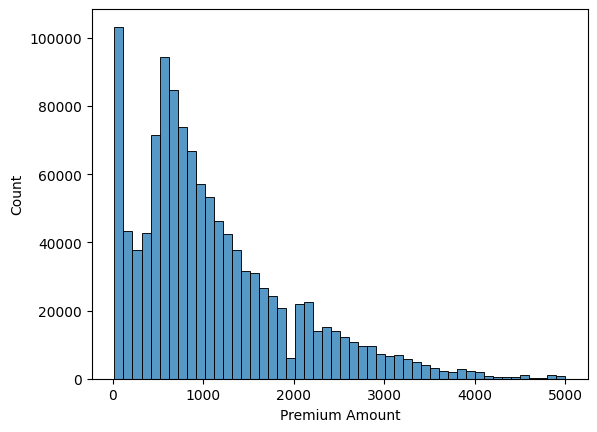

In [128]:
sns.histplot(df['Premium Amount'], bins=50)

                feature      coef  abs_coef    weight
1         Annual Income -0.103702  0.103702  1.000000
6          Credit Score -0.072315  0.072315  0.697332
4       Previous Claims  0.041619  0.041619  0.401333
3          Health Score  0.020003  0.020003  0.192889
2  Number of Dependents -0.003039  0.003039  0.029310
0                   Age -0.001571  0.001571  0.015153
5           Vehicle Age  0.000000  0.000000  0.000000
7    Insurance Duration  0.000000  0.000000  0.000000
count    1.181288e+06
mean     3.113850e-01
std      1.224905e-01
min      0.000000e+00
25%      2.296373e-01
50%      2.986764e-01
75%      3.755356e-01
max      1.000000e+00
Name: Risk_Score_Lasso_Log, dtype: float64


<Axes: xlabel='Risk_Class_Lasso_Log', ylabel='Premium Amount'>

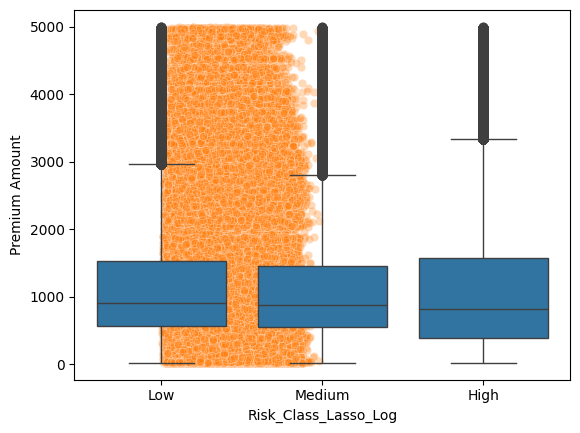

In [129]:
print(coef_df.sort_values('abs_coef', ascending=False).head(10))
print(df['Risk_Score_Lasso_Log'].describe())
sns.boxplot(x='Risk_Class_Lasso_Log', y='Premium Amount', data=df)
sns.scatterplot(x='Risk_Score_Lasso_Log', y='Premium Amount', data=df, alpha=0.3)